In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Import MNIST dataset
from tensorflow.keras.datasets import mnist

# Import neural network tools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# Convert labels to categorical format
from tensorflow.keras.utils import to_categorical

In [ ]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Print dataset shapes
print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


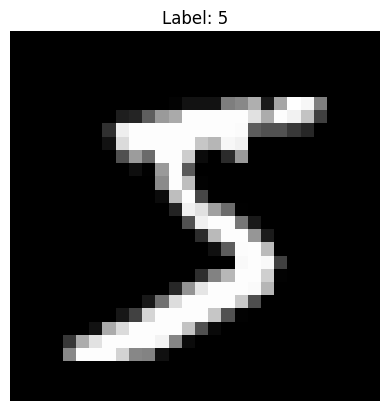

In [4]:
# Show first image
plt.imshow(x_train[0], cmap='gray')

plt.title(f"Label: {y_train[0]}")

plt.axis('off')

plt.show()

In [5]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
# Convert labels to categorical format
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [7]:
# Create first model
model = Sequential()

# Flatten layer
model.add(Flatten(input_shape=(28, 28)))

# Hidden layer with ReLU activation
model.add(Dense(128, activation='relu'))

# Dropout layer
model.add(Dropout(0.2))

# Output layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Train first model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9050 - loss: 0.3283 - val_accuracy: 0.9532 - val_loss: 0.1630
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9528 - loss: 0.1574 - val_accuracy: 0.9649 - val_loss: 0.1186
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9650 - loss: 0.1177 - val_accuracy: 0.9675 - val_loss: 0.1029
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9712 - loss: 0.0960 - val_accuracy: 0.9716 - val_loss: 0.0916
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9748 - loss: 0.0806 - val_accuracy: 0.9732 - val_loss: 0.0883
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9776 - loss: 0.0712 - val_accuracy: 0.9736 - val_loss: 0.0861
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9808 - loss: 0.0617 - val_accuracy: 0.9758 - val_loss: 0.0853
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9819 - loss: 0.0562 -

In [11]:
# Evaluate first model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("ReLU Model Results")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9798 - loss: 0.0709
ReLU Model Results
Test Loss: 0.07088914513587952
Test Accuracy: 0.9797999858856201


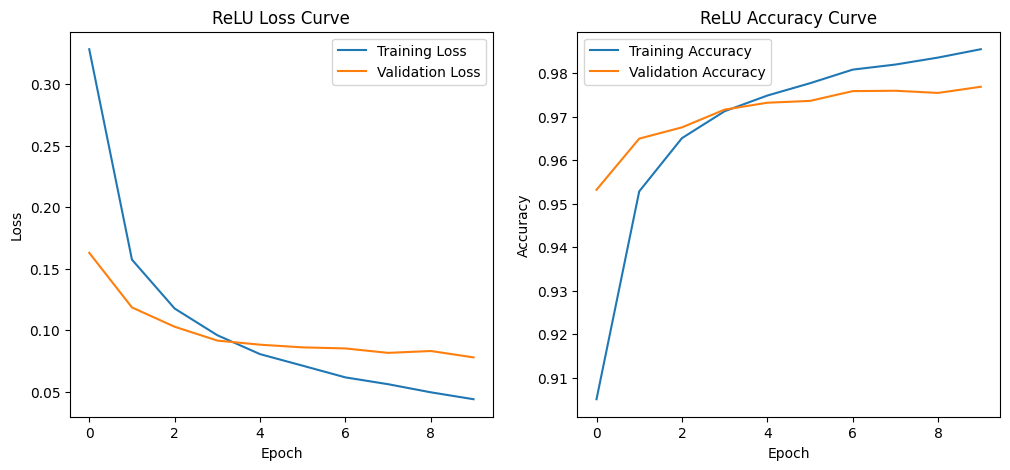

In [16]:
# Create figure with 2 plots side by side
plt.figure(figsize=(12,5))

# ---------------- Loss Curve ----------------
plt.subplot(1,2,1)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('ReLU Loss Curve')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

# ---------------- Accuracy Curve ----------------
plt.subplot(1,2,2)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('ReLU Accuracy Curve')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [17]:
# Create second model
model2 = Sequential()

# Flatten layer
model2.add(Flatten(input_shape=(28, 28)))

# Hidden layer with Tanh activation
model2.add(Dense(128, activation='tanh'))

# Dropout layer
model2.add(Dropout(0.2))

# Output layer
model2.add(Dense(10, activation='softmax'))

In [18]:
# Compile second model
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# Train second model
history2 = model2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8966 - loss: 0.3530 - val_accuracy: 0.9406 - val_loss: 0.2101
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9391 - loss: 0.2029 - val_accuracy: 0.9542 - val_loss: 0.1614
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9522 - loss: 0.1621 - val_accuracy: 0.9601 - val_loss: 0.1354
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9609 - loss: 0.1314 - val_accuracy: 0.9625 - val_loss: 0.1298
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9647 - loss: 0.1128 - val_accuracy: 0.9669 - val_loss: 0.1134
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9686 - loss: 0.1010 - val_accuracy: 0.9689 - val_loss: 0.1042
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9713 - loss: 0.0898 - val_accuracy: 0.9693 - val_loss: 0.1001
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9746 - loss: 0.0801 - 

In [20]:
# Evaluate second model
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)

print("Tanh Model Results")
print("Test Loss:", test_loss2)
print("Test Accuracy:", test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9725 - loss: 0.0854
Tanh Model Results
Test Loss: 0.08543816953897476
Test Accuracy: 0.9725000262260437


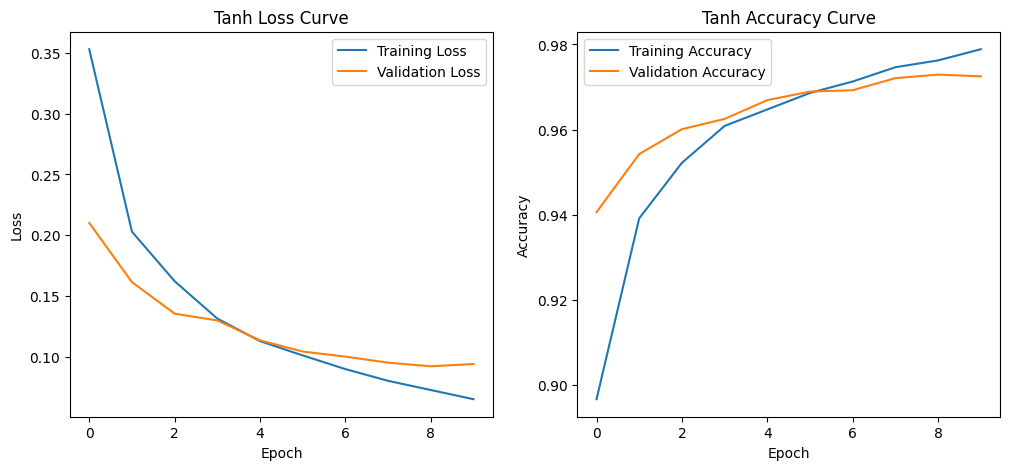

In [21]:
# Create figure with 2 plots side by side
plt.figure(figsize=(12,5))

# ---------------- Loss Curve ----------------
plt.subplot(1,2,1)

plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.title('Tanh Loss Curve')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

# ---------------- Accuracy Curve ----------------
plt.subplot(1,2,2)

plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')

plt.title('Tanh Accuracy Curve')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [22]:
# Compare both experiments

print("===== ReLU Model =====")
print("Accuracy:", test_accuracy)
print("Loss:", test_loss)

print("\n===== Tanh Model =====")
print("Accuracy:", test_accuracy2)
print("Loss:", test_loss2)

===== ReLU Model =====
Accuracy: 0.9797999858856201
Loss: 0.07088914513587952

===== Tanh Model =====
Accuracy: 0.9725000262260437
Loss: 0.08543816953897476
